# The Culture of Measurement
### *Modern Strain Gage Technology* — Companion Notebook

**A good measurement is a habit before it is a result** — the organizational habit of catching a missing zero reference or an unverified excitation voltage *before* data collection, not after something goes wrong.

Companion notebook to Chapter 7 — The Culture of Measurement.

Measurement culture is not the sum of individual technical skills. It is the organizational substrate — the habits, procedures, and norms — that determines whether measurements are planned carefully, executed correctly, documented fully, and used appropriately. An organization with strong measurement culture does not need to be reminded to perform shunt calibration, record environmental conditions, or archive raw data in a non-proprietary format. These things happen automatically because they are part of how the organization works.

The gap between knowing what to do and actually doing it is where most measurement failures originate. The pre-test readiness checklist converts professional judgment into a binary check: satisfied or not. Items marked critical — excitation voltage unverified, sample rate below Nyquist, zero reference not recorded — should stop the test. Advisory items represent systematic weaknesses that compound over time. Building the checklist before the test begins, not after something goes wrong, is the defining habit of a measurement-mature organization.

The **error budget** is the quantitative complement to the checklist. Before testing begins, the engineer should estimate how large each uncertainty source is, which sources dominate, and whether the combined uncertainty meets the measurement objective. A budget dominated by thermal apparent strain (a correctable systematic error) requires a different response than one dominated by gage factor tolerance (a fixed material property). The Pareto chart makes this prioritization visible: cutting the largest variance contributor in half saves more than eliminating a small one entirely.

**This notebook demonstrates:**
1. **Pre-test readiness checklist** — configurable status visualization with critical-gap (★) and advisory-gap classification by phase.
2. **Error budget** — sorted uncertainty contributions with RSS combined uncertainty, worst-case bound, and a Pareto variance chart identifying the dominant sources.

These are the working artifacts of the culture Tatnall, Starr, and Stein built: measurement treated as a system of reasoning, planned before the first reading is taken.

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All notebook figures are written here; the book includes these exact files.
OUT_DIR = Path("../src/media/ch07")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Pre-Test Readiness: Configurable Checklist

A pre-test readiness checklist is a forcing function. It converts the diffuse responsibility of "be careful" into a specific, auditable list of verified conditions. The items in this checklist are organized by phase — hardware and installation, calibration, data acquisition, documentation — and each is flagged as either critical (a gap should stop the test) or advisory (a gap warrants attention but may not require an immediate halt).

The criticality classification reflects the asymmetry of consequences. An unverified excitation voltage introduces a systematic multiplier error into every reading — there is no post-processing correction for this because you don't know what the true voltage was. A missing post-test shunt calibration is serious but recoverable if the pre-test shunt calibration is documented. An unarchived raw data file is advisory until it is needed in a legal proceeding; then it is catastrophic.

Modify the `checklist` dictionary in the code cell to match your own test configuration. Set each item to `(1, critical)` (satisfied) or `(0, critical)` (gap). The visualization color-codes each item by status, and the printed summary at the bottom lists all critical gaps and advisory gaps by name so the responsible engineer can resolve them before proceeding.

Set each item to `1` (satisfied) or `0` (gap), then run the cell. Items marked **★** are critical — a gap there should stop the test. Advisory items warrant attention but may not require an immediate halt. Items are grouped by phase.

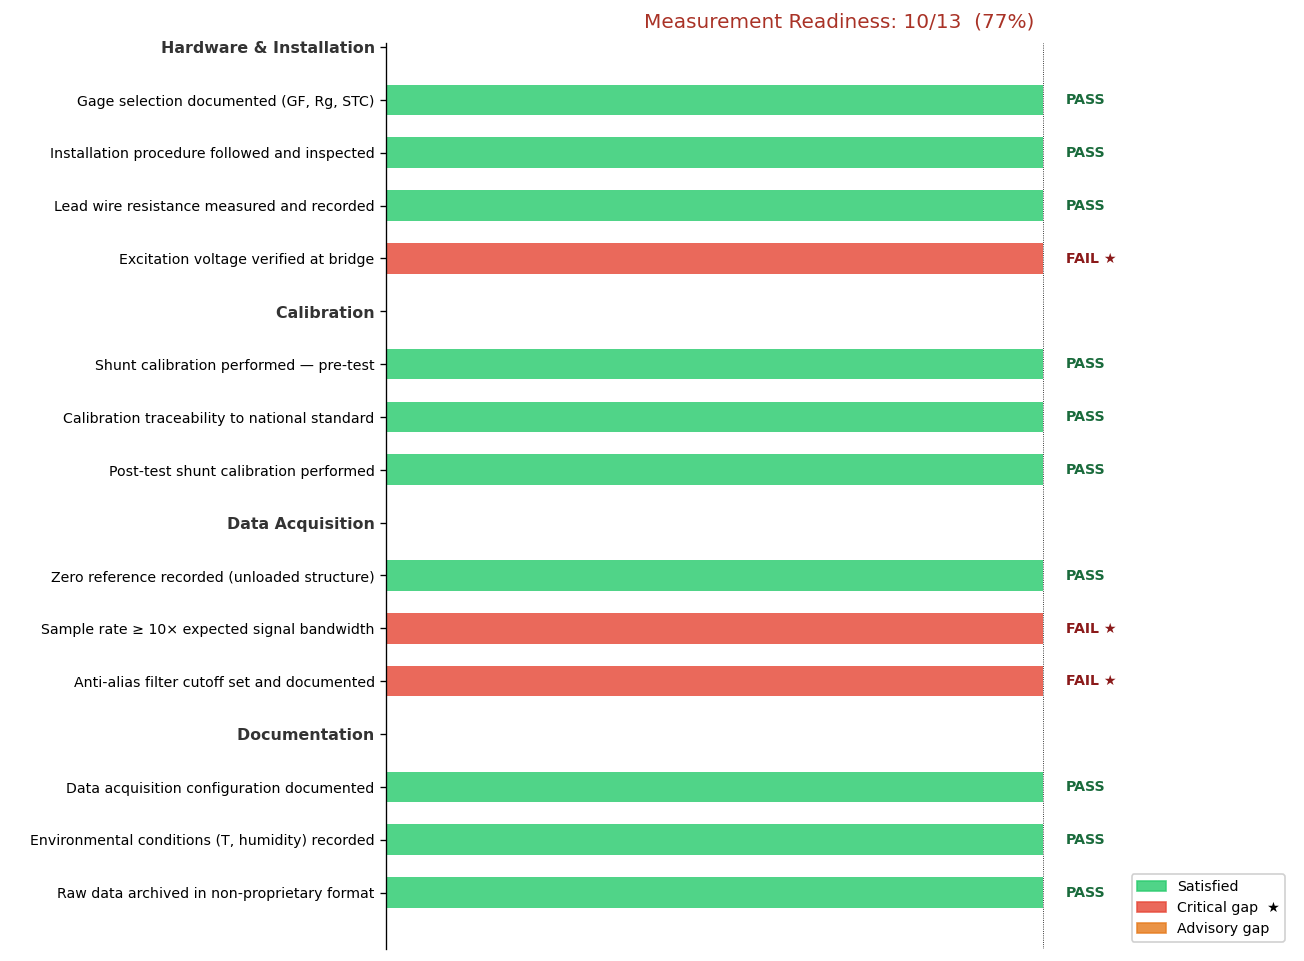


Readiness: 10/13  (77%)
CRITICAL — resolve before proceeding:
  ★  Excitation voltage verified at bridge
  ★  Sample rate ≥ 10× expected signal bandwidth
  ★  Anti-alias filter cutoff set and documented


In [2]:
# --- USER INPUT ---
# Format:  "Description": (satisfied, critical)
# critical=True → a FAIL here should stop the test
checklist = {
    "Hardware & Installation": {
        "Gage selection documented (GF, Rg, STC)":         (1, True),
        "Installation procedure followed and inspected":    (1, True),
        "Lead wire resistance measured and recorded":       (1, True),
        "Excitation voltage verified at bridge":            (0, True),
    },
    "Calibration": {
        "Shunt calibration performed — pre-test":           (1, True),
        "Calibration traceability to national standard":    (1, False),
        "Post-test shunt calibration performed":            (1, False),
    },
    "Data Acquisition": {
        "Zero reference recorded (unloaded structure)":     (1, True),
        "Sample rate ≥ 10× expected signal bandwidth":      (0, True),
        "Anti-alias filter cutoff set and documented":      (0, True),
    },
    "Documentation": {
        "Data acquisition configuration documented":        (1, False),
        "Environmental conditions (T, humidity) recorded":  (1, False),
        "Raw data archived in non-proprietary format":      (1, False),
    },
}

# Status color palette (satisfied / critical gap / advisory gap)
COLOR_PASS     = '#2ecc71'
COLOR_CRITICAL = '#e74c3c'
COLOR_ADVISORY = '#e67e22'

# Flatten: (display_label, bar_color_or_None, is_header, tag, tag_color)
entries = []
for group, items in checklist.items():
    entries.append((f"  {group}", None, True, "", ""))
    for desc, (sat, crit) in items.items():
        bar_color = COLOR_PASS if sat else (COLOR_CRITICAL if crit else COLOR_ADVISORY)
        tag       = 'PASS' if sat else ('FAIL ★' if crit else 'GAP')
        tag_color = '#1a6b3c' if sat else ('#8b1a1a' if crit else '#7d4000')
        entries.append((f"    {desc}", bar_color, False, tag, tag_color))

n = len(entries)

fig, ax = plt.subplots(figsize=(11, max(5, 0.42 * n + 1.0)))

for i, (label, color, is_hdr, tag, tc) in enumerate(entries):
    y = n - 1 - i
    if not is_hdr:
        ax.barh(y, 1, color=color, alpha=0.84, height=0.58, zorder=2)
        ax.text(1.035, y, tag, va='center', fontsize=8.5, color=tc, fontweight='bold')

ax.set_yticks(range(n))
ax.set_yticklabels([e[0] for e in entries][::-1], fontsize=8.5)

for tick, (_, _, is_hdr, _, _) in zip(ax.get_yticklabels(), entries[::-1]):
    if is_hdr:
        tick.set_fontweight('bold')
        tick.set_fontsize(9.5)
        tick.set_color('#333333')

ax.set_xlim(0, 1.38)
ax.set_xticks([])
ax.axvline(1.0, color='black', lw=0.5, linestyle=':')
ax.grid(True, axis='x', linestyle=':', alpha=0.25, zorder=1)
ax.spines[['top', 'right', 'bottom']].set_visible(False)

all_items   = [(s, c) for items in checklist.values() for _, (s, c) in items.items()]
n_total     = len(all_items)
n_pass      = sum(s for s, _ in all_items)
pct         = 100 * n_pass / n_total
crit_fails  = [d for items in checklist.values() for d, (s, c) in items.items() if not s and c]
adv_gaps    = [d for items in checklist.values() for d, (s, c) in items.items() if not s and not c]

color_t = '#1a7a45' if pct == 100 else ('#e67e22' if pct >= 80 else '#a93226')
ax.set_title(f'Measurement Readiness: {n_pass}/{n_total}  ({pct:.0f}%)',
             color=color_t, fontsize=12, pad=10)

patches = [
    mpatches.Patch(color=COLOR_PASS, alpha=0.84, label='Satisfied'),
    mpatches.Patch(color=COLOR_CRITICAL, alpha=0.84, label='Critical gap  ★'),
    mpatches.Patch(color=COLOR_ADVISORY, alpha=0.84, label='Advisory gap'),
]
ax.legend(handles=patches, loc='lower right', fontsize=8.5, framealpha=0.9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig07_nb1_readiness_checklist.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nReadiness: {n_pass}/{n_total}  ({pct:.0f}%)")
if crit_fails:
    print("CRITICAL — resolve before proceeding:")
    for d in crit_fails:
        print(f"  ★  {d}")
if adv_gaps:
    print("Advisory gaps:")
    for d in adv_gaps:
        print(f"     {d}")
if not crit_fails and not adv_gaps:
    print("All items satisfied. Program is ready to proceed.")

---
## 2 — Error Budget: Sorted Uncertainty Contributions and Pareto Analysis

An error budget built before the test is a planning tool. An error budget built after the test is a post-mortem. The goal is to estimate — for each uncertainty source — how large its contribution will be under realistic test conditions, and then to identify which sources dominate the total so that effort can be directed where it matters.

The RSS (root sum of squares) combination assumes the sources are independent and uncorrelated. This is correct for true random errors (ADC noise, amplifier offset drift, shunt calibration uncertainty) but not for systematic errors that may be correlated across channels or over time. The worst-case sum is the conservative bound for correlated systematic errors. In practice, most budgets contain both types, and the RSS and worst-case values bracket the true combined uncertainty.

The Pareto chart on the right makes the prioritization immediately visible. In this example, thermal apparent strain and lead wire resistance dominate — these are the sources worth reducing. Cutting the thermal contribution in half (by improving temperature compensation or controlling the thermal environment) saves more combined uncertainty than eliminating the ADC quantization entirely. The sensitivity table printed at the bottom shows precisely how much each source reduction would improve the RSS total.

An **error budget** assigns a magnitude to each uncertainty source *before* the test — surprises discovered in post-processing are far more expensive to resolve. Sources are classified as **random** (reducible by averaging) or **systematic** (fixed bias; repetition doesn't help).

- **RSS** is the correct combination for independent, uncorrelated sources.
- **Worst-case sum** applies when sources may be correlated — the conservative bound.
- The **Pareto chart** shows which sources dominate total variance. That's where effort pays off: cutting the largest contributor in half beats eliminating a small one entirely.

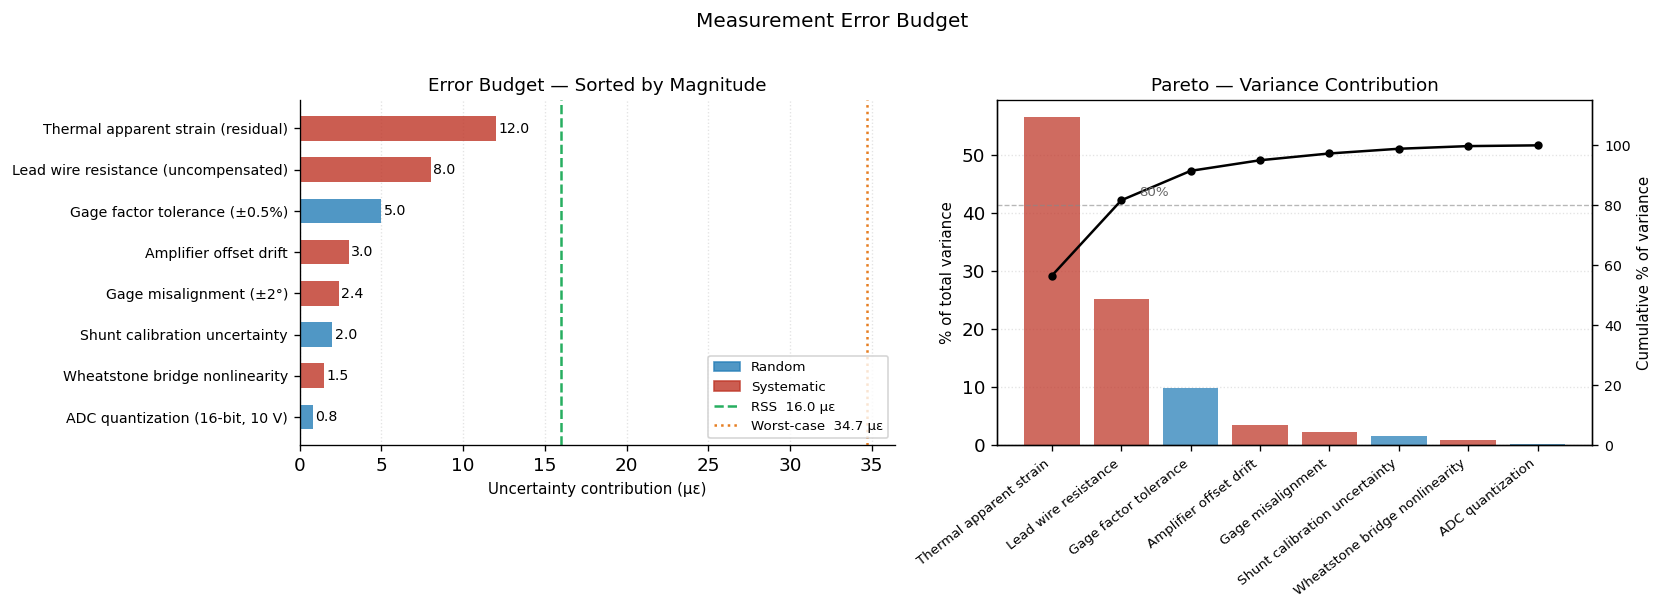

RSS combined uncertainty:    16.0 με
Worst-case (linear) sum:     34.7 με
Random-only RSS:             5.4 με
Systematic-only sum:         26.9 με  (correlated — cannot RSS)

Sensitivity — new RSS if each source is halved:
  Source                                        New RSS      Saved
  -------------------------------------------  --------  ---------
  Thermal apparent strain (residual)              12.1       +3.8 με
  Lead wire resistance (uncompensated)            14.4       +1.6 με
  Gage factor tolerance (±0.5%)                   15.4       +0.6 με
  Amplifier offset drift                          15.7       +0.2 με
  Gage misalignment (±2°)                         15.8       +0.1 με
  Shunt calibration uncertainty                   15.9       +0.1 με
  Wheatstone bridge nonlinearity                  15.9       +0.1 με
  ADC quantization (16-bit, 10 V)                 15.9       +0.0 με


In [3]:
# --- USER INPUT ---
# Each entry: (magnitude in με, 'random' or 'systematic')
# Use values appropriate to your expected load level (here: ~1000 με)
error_sources = {
    "Gage factor tolerance (±0.5%)":         (5.0,  'random'),
    "Wheatstone bridge nonlinearity":         (1.5,  'systematic'),
    "Lead wire resistance (uncompensated)":   (8.0,  'systematic'),
    "Thermal apparent strain (residual)":    (12.0,  'systematic'),
    "ADC quantization (16-bit, 10 V)":        (0.8,  'random'),
    "Amplifier offset drift":                 (3.0,  'systematic'),
    "Gage misalignment (±2°)":               (2.4,  'systematic'),
    "Shunt calibration uncertainty":          (2.0,  'random'),
}

PARETO_THRESHOLD = 80          # % of cumulative variance marking the "vital few" sources

# Palette: random sources are reducible by averaging; systematic sources are fixed bias.
COLOR_RANDOM     = '#2980b9'
COLOR_SYSTEMATIC = '#c0392b'


def rss(contributions):
    """Root sum of squares — the correct combination for independent, uncorrelated sources."""
    return np.sqrt(np.sum(np.square(contributions)))


names  = list(error_sources.keys())
values = np.array([v for v, _ in error_sources.values()])
types  = [t for _, t in error_sources.values()]

order    = np.argsort(values)[::-1]
names_s  = [names[i]  for i in order]
values_s = values[order]
types_s  = [types[i]  for i in order]
colors_s = [COLOR_RANDOM if t == 'random' else COLOR_SYSTEMATIC for t in types_s]

rss_total = rss(values)
worst     = np.sum(values)
cum_pct   = np.cumsum(values_s**2) / np.sum(values_s**2) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: sorted bar chart ---
ax1.barh(range(len(names_s)), values_s, color=colors_s, alpha=0.82, height=0.6, zorder=2)
ax1.set_yticks(range(len(names_s)))
ax1.set_yticklabels(names_s, fontsize=8.5)
ax1.invert_yaxis()
ax1.set_xlabel('Uncertainty contribution (με)', fontsize=9)
ax1.set_title('Error Budget — Sorted by Magnitude', fontsize=11)
for i, val in enumerate(values_s):
    ax1.text(val + 0.15, i, f'{val:.1f}', va='center', fontsize=8.5)

l_rss   = ax1.axvline(rss_total, color='#27ae60', lw=1.5, linestyle='--', label=f'RSS  {rss_total:.1f} με')
l_worst = ax1.axvline(worst,     color='#e67e22', lw=1.5, linestyle=':',  label=f'Worst-case  {worst:.1f} με')
ax1.grid(True, axis='x', linestyle=':', alpha=0.35, zorder=1)
ax1.spines[['top', 'right']].set_visible(False)

r_patch = mpatches.Patch(color=COLOR_RANDOM, alpha=0.82, label='Random')
s_patch = mpatches.Patch(color=COLOR_SYSTEMATIC, alpha=0.82, label='Systematic')
ax1.legend(handles=[r_patch, s_patch, l_rss, l_worst], fontsize=8, loc='lower right')

# --- Right: Pareto (variance contribution) ---
xp = np.arange(len(names_s))
ax2.bar(xp, values_s**2 / np.sum(values_s**2) * 100,
        color=colors_s, alpha=0.75, zorder=2)
ax2r = ax2.twinx()
ax2r.plot(xp, cum_pct, 'k-o', ms=4, lw=1.5, zorder=3, label='Cumulative %')
ax2r.axhline(PARETO_THRESHOLD, color='#888888', lw=0.8, linestyle='--', alpha=0.6)
idx80 = next(i for i, c in enumerate(cum_pct) if c >= PARETO_THRESHOLD)
ax2r.annotate(f'{PARETO_THRESHOLD}%', xy=(idx80, PARETO_THRESHOLD),
              xytext=(idx80 + 0.25, PARETO_THRESHOLD + 3),
              fontsize=8, color='#666666')
ax2r.set_ylim(0, 115)
ax2r.set_ylabel('Cumulative % of variance', fontsize=9)
ax2r.tick_params(labelsize=8.5)

short = [n.split('(')[0].strip() for n in names_s]
ax2.set_xticks(xp)
ax2.set_xticklabels(short, rotation=38, ha='right', fontsize=8)
ax2.set_ylabel('% of total variance', fontsize=9)
ax2.set_title('Pareto — Variance Contribution', fontsize=11)
ax2.grid(True, axis='y', linestyle=':', alpha=0.35, zorder=1)
ax2.spines[['top']].set_visible(False)

plt.suptitle('Measurement Error Budget', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig07_nb2_error_budget_pareto.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Summary ---
rand_mask = np.array([t == 'random'     for t in types])
syst_mask = np.array([t == 'systematic' for t in types])
print(f"RSS combined uncertainty:    {rss_total:.1f} με")
print(f"Worst-case (linear) sum:     {worst:.1f} με")
print(f"Random-only RSS:             {rss(values[rand_mask]):.1f} με")
print(f"Systematic-only sum:         {np.sum(values[syst_mask]):.1f} με  (correlated — cannot RSS)")

print(f"\nSensitivity — new RSS if each source is halved:")
print(f"  {'Source':<43}  {'New RSS':>8}  {'Saved':>9}")
print(f"  {'-'*43}  {'-'*8}  {'-'*9}")
for i in order:
    m = values.copy()
    m[i] /= 2
    new_rss = rss(m)
    print(f"  {names[i]:<43}  {new_rss:>7.1f}   {rss_total - new_rss:>+8.1f} με")

---
## Where to take this next

The two artifacts above are deliberately minimal starting points. A measurement-mature organization turns them into living tools:

1. **Make the checklist self-scoring against a config file.** Store the `checklist` in a YAML or JSON test-configuration file that lives beside the raw data, and have the notebook load it, render the figure, and *refuse to proceed* (raise an exception) whenever any critical item is unsatisfied. Now the readiness gate is version-controlled and auditable alongside the results it guards.

2. **Drive the error budget from real per-source models.** Replace the hand-entered magnitudes with functions that compute each contribution from datasheet values at your actual load level — e.g. gage-factor tolerance times the measured strain, thermal apparent strain from the S-T-C curve and expected temperature swing, ADC quantization from bit depth and range. The budget then updates automatically when you change the test conditions.

3. **Propagate the budget into a reported result.** Combine the RSS uncertainty with a coverage factor (k = 2 for roughly 95% confidence) and print a complete measurement statement — *value ± expanded uncertainty (με), k = 2* — the honest, uncertainty-aware report that Peter Stein argued was an ethical obligation, not an afterthought.